# System Design of Student Performance Prediction

In [1]:
# Installations
!pip install lime
!pip install ipywidgets
!pip install imbalanced-learn==0.12.2
!pip install xgboost==2.0.3
!pip install "ipython<8.12"
!pip install pandas 
!pip install numpy 
!pip install matplotlib 
!pip install scikit-learn
!pip install shap 
!pip install flask
!pip install seaborn
!pip install --upgrade pip

In [2]:
#Load Dataset

import pandas as pd

df = pd.read_csv("result-data.csv")
df.head(20)

,Assignment,Presentation,Attendance,Quiz,MidTerm,Final,CGPA
0,4,5,3,2,7,21,2.00
1,10,9,9,8,13,25,3.50
2,10,10,10,8,11,33,4.00
3,1,1,2,0,0,2,1.25
4,4,5,5,0,1,5,1.25
5,4,1,0,3,2,4,1.25
6,6,7,5,6,8,18,2.50
7,10,8,9,9,15,30,4.00
8,5,3,5,3,9,19,2.00
9,8,8,8,3,12,28,3.25


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Assignment    2000 non-null   int64  
 1   Presentation  2000 non-null   int64  
 2   Attendance    2000 non-null   int64  
 3   Quiz          2000 non-null   int64  
 4   MidTerm       2000 non-null   int64  
 5   Final         2000 non-null   int64  
 6   CGPA          2000 non-null   float64
dtypes: float64(1), int64(6)
memory usage: 109.5 KB


Assignment      0
Presentation    0
Attendance      0
Quiz            0
MidTerm         0
Final           0
CGPA            0
dtype: int64

In [4]:
features = ["Assignment", "Presentation", "Attendance", "Quiz", "MidTerm"]
target = "Final"   # OR CGPA (depending on your dataset)

X = df[features]
y = df[target]

## MODEL SELECTION (IMPORTANT)


🔥 BEST MODELS FOR THIS CASE:
1. Gradient Boosting (TOP CHOICE)
    - XGBoost ✅ (Best accuracy)
    - LightGBM (optional)
2. Random Forest : Good baseline
3. Linear Regression For interpretability comparison

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestRegressor()

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [18]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1]
}

grid = GridSearchCV(XGBRegressor(), params, cv=5, scoring='r2')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

def evaluate(model):
    pred = model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, pred))
    print("R2:", r2_score(y_test, pred))

print("Linear Regression")
evaluate(lr)

print("Random Forest")
evaluate(rf)

print("XGBoost")
evaluate(xgb)

Linear Regression
MAE: 3.858396670977857
R2: 0.7296970619405425
Random Forest
MAE: 4.081485411255411
R2: 0.6969705049119266
XGBoost
MAE: 4.374626966863871
R2: 0.6530714242266872


In [10]:
def get_target_levels():
    return [4.00, 3.75, 3.50, 3.25, 3.00]

In [11]:
import numpy as np

def suggest_improvement(model, student_data, target_score):
    improved = student_data.copy()
    
    for feature in improved:
        while model.predict([list(improved.values())])[0] < target_score:
            improved[feature] += 1
            if improved[feature] > 100:
                break
    
    return improved

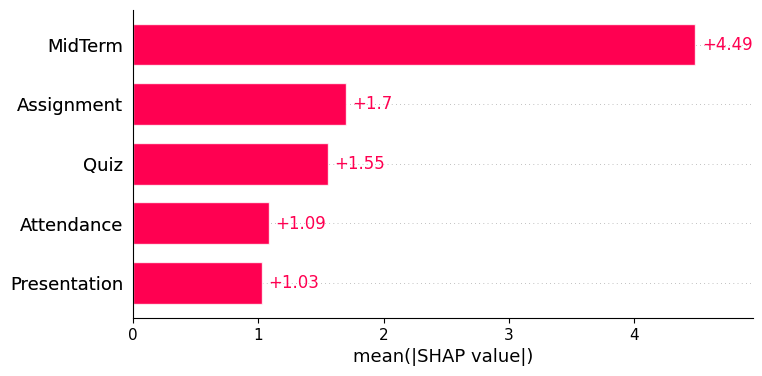

In [12]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

In [13]:
def human_feedback(predicted, actual):
    error = abs(predicted - actual)
    accuracy = 100 - (error * 25)  # custom logic
    return accuracy

In [14]:
def estimate_study_hours(improvement_gap):
    # simple heuristic
    return improvement_gap * 5

In [15]:
def full_prediction_system(student_input):
    pred = xgb.predict([student_input])[0]
    
    targets = get_target_levels()
    
    for t in targets:
        if pred >= t:
            return {
                "current_prediction": pred,
                "target": t,
                "status": "Achievable"
            }
    
    # Suggest improvement
    improved = suggest_improvement(xgb, dict(zip(features, student_input)), 3.75)
    
    return {
        "current_prediction": pred,
        "suggested_input": improved
    }